# Exercise 01 — Fourth-Order Runge-Kutta Method

## Theory

Consider a second-order ordinary differential equation

$$
\frac{d^2x}{dt^2}+\omega_0\xi\frac{dx}{dt}+\omega_0^2x=0,
$$

with initial conditions

$$
x(0)=0.01R_0,
\qquad
x'(0)=0.
$$

To apply the fourth-order Runge-Kutta method (RK4), the second-order equation is first transformed into a system of two first-order ODEs. Defining

$$
z=\frac{dx}{dt},
$$

the system becomes

$$
\frac{dx}{dt}=z,
$$

$$
\frac{dz}{dt}=-\omega_0\xi z-\omega_0^2x.
$$

Therefore,

$$
f_1(x,z)=z,
\qquad
f_2(x,z)=-\omega_0\xi z-\omega_0^2x.
$$

For a step size $h$, the RK4 method computes four intermediate approximations for each variable:

$$
k_{1x}=h f_1(x_n,z_n),
\qquad
k_{1z}=h f_2(x_n,z_n),
$$

$$
k_{2x}=h f_1\left(x_n+\frac{k_{1x}}{2},z_n+\frac{k_{1z}}{2}\right),
\qquad
k_{2z}=h f_2\left(x_n+\frac{k_{1x}}{2},z_n+\frac{k_{1z}}{2}\right),
$$

$$
k_{3x}=h f_1\left(x_n+\frac{k_{2x}}{2},z_n+\frac{k_{2z}}{2}\right),
\qquad
k_{3z}=h f_2\left(x_n+\frac{k_{2x}}{2},z_n+\frac{k_{2z}}{2}\right),
$$

$$
k_{4x}=h f_1(x_n+k_{3x},z_n+k_{3z}),
\qquad
k_{4z}=h f_2(x_n+k_{3x},z_n+k_{3z}).
$$

The solution is then updated as

$$
x_{n+1}
=
x_n+\frac{k_{1x}+2k_{2x}+2k_{3x}+k_{4x}}{6},
$$

$$
z_{n+1}
=
z_n+\frac{k_{1z}+2k_{2z}+2k_{3z}+k_{4z}}{6}.
$$

The RK4 method combines four estimates of the derivative at each time step, providing a fourth-order accurate approximation of the solution.

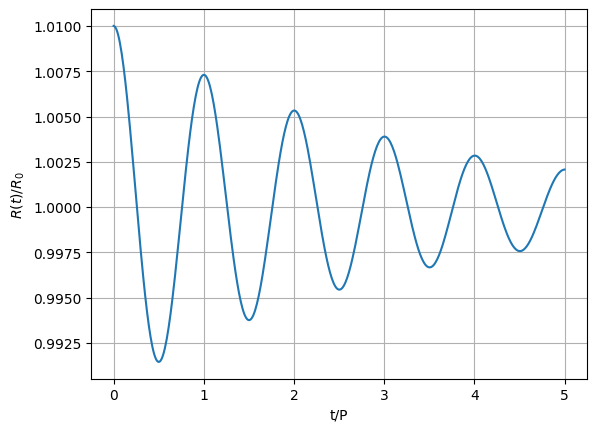

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parametros
epsilon = 0.1
R = 7*10**8
R_0 = 42.7*R
P = 4.32*10**5
w_0 = 2*np.pi/P

# Paso
h = 0.01*P

# Tiempo
t_0 = 0
t_final = 5*P

# Sistema de ecuaciones
def f1(z):
  return z

def f2(x,z):
  return -w_0*epsilon*z - w_0**2*x

# Numero de pasos
N = int((t_final-t_0)/h)

# Arrays
t = np.zeros(N+1)
x = np.zeros(N+1)
z = np.zeros(N+1)

# Condiciones iniciales
t[0] = t_0
x[0] = 0.01*R_0
z[0] = 0

# RK4
for n in range(N):

  k1_x = h*f1(z[n])
  k1_z = h*f2(x[n],z[n])

  k2_x = h*f1(z[n]+k1_z/2)
  k2_z = h*f2(x[n]+k1_x/2,z[n]+k1_z/2)

  k3_x = h*f1(z[n]+k2_z/2)
  k3_z = h*f2(x[n]+k2_x/2,z[n]+k2_z/2)

  k4_x = h*f1(z[n]+k3_z)
  k4_z = h*f2(x[n]+k3_x,z[n]+k3_z)

  x[n+1] = x[n] + (k1_x+2*k2_x+2*k3_x+k4_x)/6
  z[n+1] = z[n] + (k1_z+2*k2_z+2*k3_z+k4_z)/6

  t[n+1] = t[n] + h

# Radio de la estrella
R_t = R_0 + x

# Grafica
plt.plot(t/P,R_t/R_0)
plt.xlabel("t/P")
plt.ylabel(r"$R(t)/R_0$")
plt.grid()
plt.show()